In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import ale_py
from stable_baselines3.common.atari_wrappers import (
    NoopResetEnv,
    MaxAndSkipEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    ClipRewardEnv
)

(4, 84, 84)


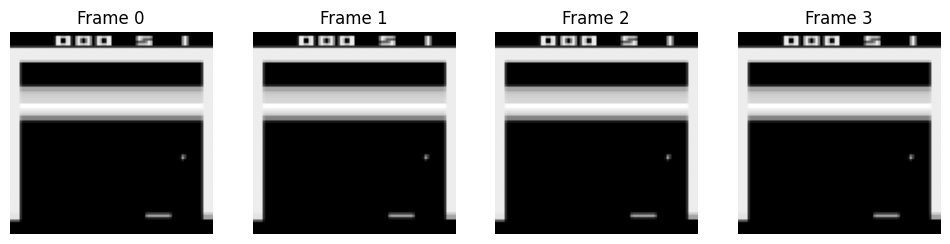

In [3]:
env = gym.make(
    "ALE/Breakout-v5",
    render_mode="rgb_array",
    frameskip=1,
    repeat_action_probability=0.0,
)

env = NoopResetEnv(env, noop_max=30)
env = MaxAndSkipEnv(env, skip=4)
env = EpisodicLifeEnv(env)

if "FIRE" in env.unwrapped.get_action_meanings():
    env = FireResetEnv(env)

env = ClipRewardEnv(env)
env = gym.wrappers.ResizeObservation(env, (84, 84))
env = gym.wrappers.GrayscaleObservation(env)
env = gym.wrappers.FrameStackObservation(env, 4)

obs, info = env.reset()

print(obs.shape)

fig, ax = plt.subplots(1,4, figsize=(12,3))

for i in range(4):
    ax[i].imshow(obs[i], cmap="gray")
    ax[i].set_title(f"Frame {i}")
    ax[i].axis("off")

plt.show()

logits tensor([[  83.8965,   19.4083, -227.6253,  151.5355]])
chosen action: LEFT
Critic Score: 506.26220703125
Action: 3, Value: 506.262


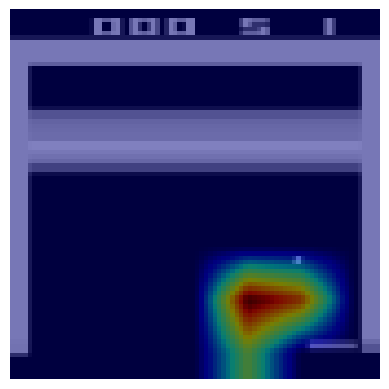

logits tensor([[ -56.7306,  -58.4080, -715.1481,  666.7895]])
chosen action: LEFT
Critic Score: 507.5217590332031
Action: 3, Value: 507.522


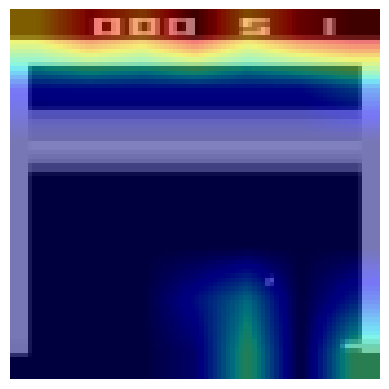

logits tensor([[ -169.7671,   -68.8090, -1882.9309,  1581.8009]])
chosen action: LEFT
Critic Score: 436.36285400390625
Action: 3, Value: 436.363


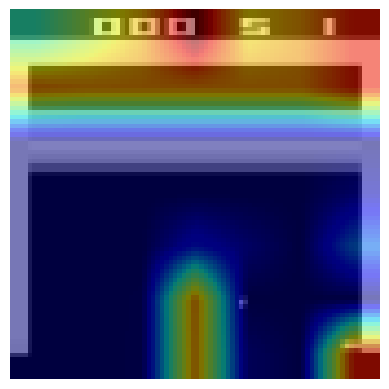

logits tensor([[  -36.2483,   -27.0505, -1312.9408,  1037.8036]])
chosen action: LEFT
Critic Score: 440.88067626953125
Action: 3, Value: 440.881


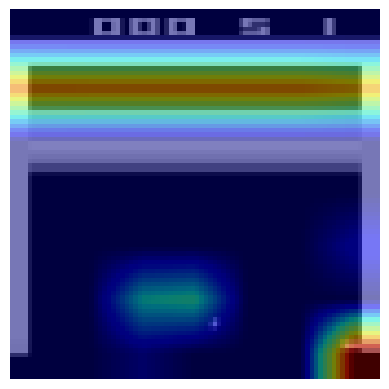

logits tensor([[  163.9278,   160.3817, -1009.4277,   470.4427]])
chosen action: LEFT
Critic Score: 433.6863098144531
Action: 3, Value: 433.686


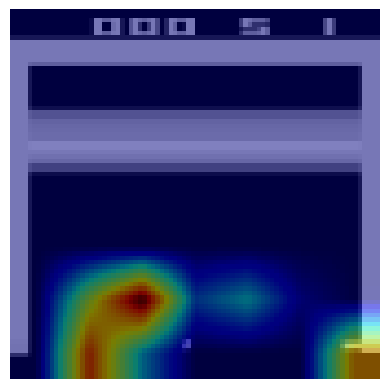

logits tensor([[ -40.0042,  -22.6186, -445.0461,  457.4782]])
chosen action: LEFT
Critic Score: 498.33740234375
Action: 3, Value: 498.337


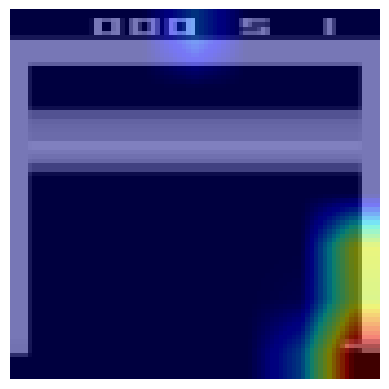

logits tensor([[ -40.0042,  -22.6186, -445.0461,  457.4782]])
chosen action: LEFT
Critic Score: 498.33740234375
Action: 3, Value: 498.337


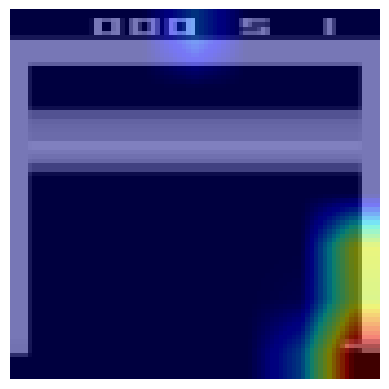

logits tensor([[  29.9812,   -7.4634, -626.6116,  526.9392]])
chosen action: LEFT
Critic Score: 438.53350830078125
Action: 3, Value: 438.534


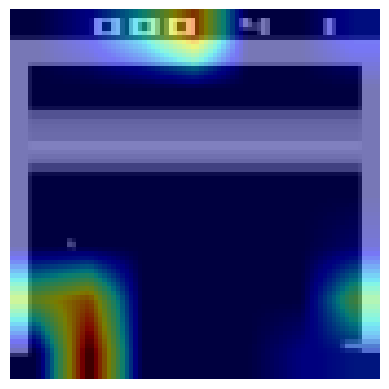

logits tensor([[ -44.2176,   23.9513, -612.1301,  529.9927]])
chosen action: LEFT
Critic Score: 393.47271728515625
Action: 3, Value: 393.473


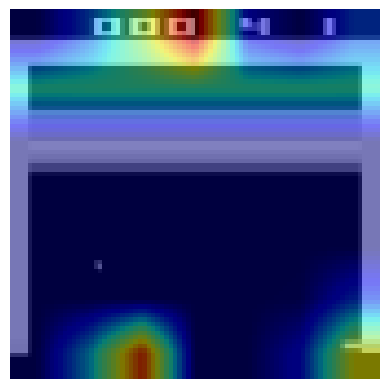

logits tensor([[ -70.0047,   26.5191, -544.4981,  518.0270]])
chosen action: LEFT
Critic Score: 412.11358642578125
Action: 3, Value: 412.114


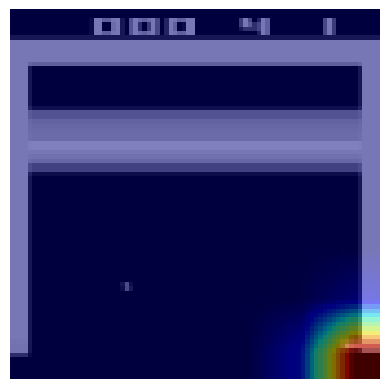

In [4]:
import torch
import torch.nn as nn
from collections import OrderedDict
from typing import Sequence, Type
import math
import datetime as dt

from src.networks import NaturePPOSharedActorCritic, NaturePPOActorCritic, PPOActorHead, PPOCriticHead


def NaturePPOSharedActorCritic(obs_shape, num_actions, **kwargs):
    actor_critic = NaturePPOActorCritic(obs_shape, num_actions, **kwargs)
    return PPOActorHead(actor_critic), PPOCriticHead(actor_critic)
# === End network definitions ===

def strip_ddp_prefix(state_dict, prefix="module."):
    """Remove 'module.0.module.0.module.' prefixes from state_dict keys"""
    new_sd = OrderedDict()
    for k, v in state_dict.items():
        name = k
        # Keep stripping 'module.X.' until no more
        while "module." in name:
            parts = name.split(".")
            # find first occurrence of 'module' and remove it + next part
            if "module" in parts:
                idx = parts.index("module")
                parts.pop(idx) # remove 'module'
                if idx < len(parts) and parts[idx].isdigit(): # remove '0'
                    parts.pop(idx)
                name = ".".join(parts)
            else:
                break
        new_sd[name] = v
    return new_sd

def load_torchrl_ppo_checkpoint(
    ckpt_path: str,
    obs_shape: tuple = (4, 84, 84),
    num_actions: int = 6,
    device: str = "cpu"
):
    # 1. Build networks with your config
    cfg = dict(
        num_cells_cnn=[32, 64, 64],
        kernel_sizes=[8, 4, 3],
        strides=[4, 2, 1],
        hidden_features=512,
        scale_pixels=False, # your config
        activation_class=nn.ReLU,
    )

    actor, critic = NaturePPOSharedActorCritic(obs_shape, num_actions, **cfg)

    # 2. Load checkpoint - it's a TrainingState object, not a dict
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    # TrainingState has attributes: step, policy_state_dict, optimizer_state_dict, etc
    # print("Loaded TrainingState at step:", ckpt.step)
    # print("Available attrs:", dir(ckpt))

    # 3. Extract the policy weights
    if not hasattr(ckpt, 'policy_state_dict'):
        raise ValueError(f"TrainingState missing policy_state_dict. Has: {dir(ckpt)}")

    policy_sd = ckpt.policy_state_dict # this is a dict: {'actor': OrderedDict, 'critic': OrderedDict}
    # print("Policy keys:", policy_sd.keys())

    actor_sd = policy_sd["actor"]
    critic_sd = policy_sd["critic"]

    # 4. Strip DDP prefixes: 'module.0.module.0.module.actor_critic.cnn_network.0.weight'
    # becomes 'actor_critic.cnn_network.0.weight'
    actor_sd = strip_ddp_prefix(actor_sd)
    critic_sd = strip_ddp_prefix(critic_sd)

    # 5. Load into your nets
    actor.load_state_dict(actor_sd, strict=False)
    critic.load_state_dict(critic_sd, strict=False)

    actor.eval()
    critic.eval()
    shared_base = actor.actor_critic

    # print("Successfully loaded weights from step", ckpt.step)
    return actor, critic, shared_base

# === Grad-CAM setup ===
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class ActorWrapper(nn.Module):
    def __init__(self, actor):
        super().__init__()
        self.actor = actor
    def forward(self, x):
        return self.actor(x)

class CriticWrapper(nn.Module):
    def __init__(self, critic):
        super().__init__()
        self.critic = critic
    def forward(self, x):
        return self.critic(x)

if __name__ == "__main__":
    CKPT =input("give path to model checkpoint")
    
    OBS_SHAPE = (4, 84, 84)
    NUM_ACTIONS = 4 # Breakout=4, Pong=6, etc
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    action_map = {
        0: "NOOP",
        1: "FIRE",
        2: "RIGHT",
        3: "LEFT"
    }

    actor, critic, shared = load_torchrl_ppo_checkpoint(CKPT, OBS_SHAPE, NUM_ACTIONS, DEVICE)

    # Target layer for Grad-CAM: last conv before flatten
    target_layers = [shared.cnn_network[4]] # Conv2d(64, 64, 3, stride=1)

    actor_cam = GradCAM(model=ActorWrapper(actor), target_layers=target_layers)
    critic_cam = GradCAM(model=CriticWrapper(critic), target_layers=target_layers)

    for i in range(10):
        obs_np, info = env.reset()
        obs = torch.tensor(obs_np).unsqueeze(0).float().to(DEVICE)
        
        # print('shape of input: ', obs.shape )

        with torch.no_grad():
            logits = actor(obs)
            print('logits', logits)
            action = logits.argmax(1).item()
            print(f"chosen action: {action_map.get(action, 'UNKNOWN')}")
            value = critic(obs).item()
            print(f'Critic Score: {value}')

        print(f"Action: {action}, Value: {value:.3f}")

        actor_heatmap = actor_cam(input_tensor=obs, targets=[ClassifierOutputTarget(action)])
        critic_heatmap = critic_cam(input_tensor=obs, targets=None)

        plt.imshow(obs[0,3].cpu(), cmap='gray')
        plt.imshow(actor_heatmap[0], cmap='jet', alpha=0.5)
        plt.axis('off')
        plt.savefig(f'outputs/{action_map.get(action, "UNKNOWN")}__{dt.datetime.now()}.png')
        plt.show()